<a href="https://colab.research.google.com/github/duddet01/Biological_modeling/blob/main/Voltage_Gate_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#---Neurobiology Homework---
Chinmoy Saikia  
20231074

In [ ]:


import numpy as np
import matplotlib.pyplot as plt


# Q1. GHK I–V Relationship

We want to compute ionic currents across a membrane using the **Goldman–Hodgkin–Katz (GHK) equation**.  
The total current is the sum of contributions from K⁺, Na⁺, Cl⁻, and Ca²⁺.  
We then normalize by the maximum absolute current so the relative contributions are clear.


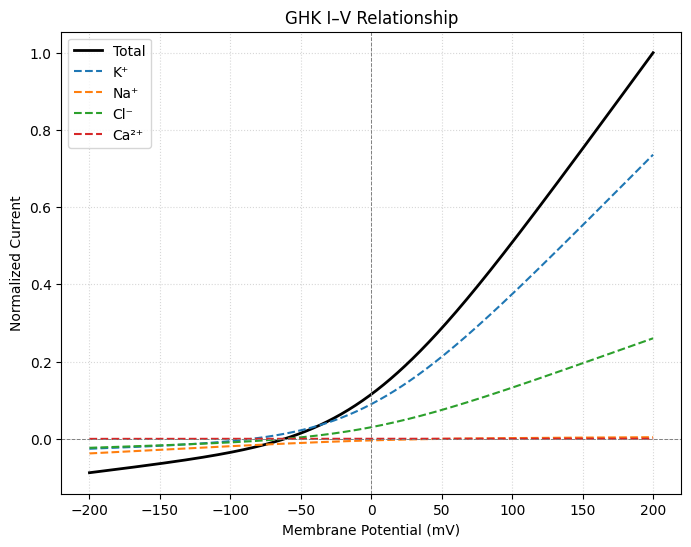

In [ ]:
# --- Q1: GHK Currents ---

# Constants
R_gas = 8.314     # J/(mol·K)
Temp  = 293       # Kelvin
Farad = 96485     # C/mol

# Concentrations (mM)
conc_in  = {'K':140, 'Na':15, 'Cl':10, 'Ca':0.0001}
conc_out = {'K':5,   'Na':145,'Cl':110,'Ca':2}

# Permeabilities
perm = {'K':1.0, 'Na':0.05, 'Cl':0.45, 'Ca':0.01}

# Valences
val = {'K':+1, 'Na':+1, 'Cl':-1, 'Ca':+2}

# Voltage sweep (V)
Vm = np.linspace(-0.2,0.2,800)  # -200 mV to +200 mV

def ghk_current(V, P, z, c_in, c_out):
    # safe voltages to avoid 0/0
    V = np.where(np.abs(V)<1e-9, 1e-9, V)
    num = P * (z**2) * (V*Farad**2/(R_gas*Temp)) * (c_in - c_out*np.exp(-z*Farad*V/(R_gas*Temp)))
    den = 1 - np.exp(-z*Farad*V/(R_gas*Temp))
    return num/den

# Individual currents
Ik  = ghk_current(Vm, perm['K'],  val['K'],  conc_in['K'],  conc_out['K'])
Ina = ghk_current(Vm, perm['Na'], val['Na'], conc_in['Na'], conc_out['Na'])
Icl = ghk_current(Vm, perm['Cl'], val['Cl'], conc_in['Cl'], conc_out['Cl'])
Ica = ghk_current(Vm, perm['Ca'], val['Ca'], conc_in['Ca'], conc_out['Ca'])

# Total
I_tot = Ik + Ina + Icl + Ica

# Normalize
scale = np.max(np.abs(I_tot))
Ik, Ina, Icl, Ica, I_tot = Ik/scale, Ina/scale, Icl/scale, Ica/scale, I_tot/scale

# Plot
plt.figure(figsize=(8,6))
plt.plot(Vm*1e3, I_tot, 'k-', lw=2, label="Total")
plt.plot(Vm*1e3, Ik,  '--', label="K⁺")
plt.plot(Vm*1e3, Ina, '--', label="Na⁺")
plt.plot(Vm*1e3, Icl, '--', label="Cl⁻")
plt.plot(Vm*1e3, Ica, '--', label="Ca²⁺")
plt.axhline(0, color='gray', linestyle='--', lw=0.7)
plt.axvline(0, color='gray', linestyle='--', lw=0.7)
plt.xlabel("Membrane Potential (mV)")
plt.ylabel("Normalized Current")
plt.title("GHK I–V Relationship")
plt.legend()
plt.grid(alpha=0.5, linestyle=':')
plt.show()


### Q1(c). Notes on the I–V Curves

On comparing the total I–V relationship with the individual ions, the total current most closely follows the **K⁺ curve**.  
This is beacuse near resting membrane potential, the membrane is far more permeable to potassium than to the other ions.  
As a result, potassium largely shapes the overall current profile.  

At negative potentials, Na- current dominates due to its high permeability and concentration gradient.

Cl- contributes moderately across all voltages due to its intermediate permeability.

In contrast, **Ca²⁺ barely contributes** to the total current.  
Its curve stays almost flat, which reflects both its very low intracellular concentration and its small permeability relative to K⁺, Na⁺, and Cl⁻.


--------------------------------------------------------------------------------

# Q2. Single Energy Barrier Model

Now we use the **single barrier model**.  
The current is given by:

$$
I(V) = zF\beta_0 \left( C_{in} e^{-\delta zFV/RT} - C_{out} e^{(1-\delta) zFV/RT} \right)
$$

- δ = 0 → barrier inside → outward rectification  
- δ = 0.5 → barrier in middle → symmetric curve  
- δ = 1 → barrier outside → inward rectification  


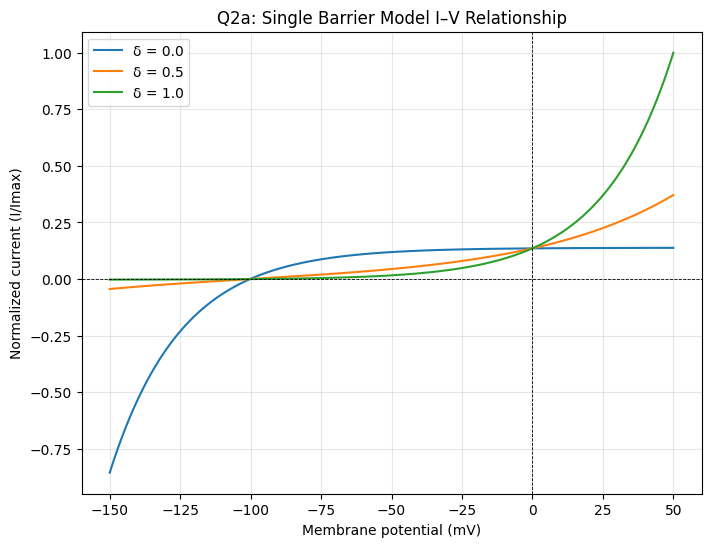

In [ ]:
# Q2. Single Barrier Model

import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
F, R, T = 96500, 8.314, 293   # Faraday const, Gas const, Temp
Cin, Cout, z = 53.0, 1.0, +1
bk0 = 1.0

# --- Single Barrier Current Function ---
def single_barrier_current(V, delta):
    """Compute I–V relation for single energy barrier model."""
    a = (z*F*V)/(R*T)
    c_in_term  = Cin  * np.exp(delta * a)
    c_out_term = Cout * np.exp(-(1-delta) * a)
    return z * F * bk0 * (c_in_term - c_out_term)

# Voltage range: -150 mV to +50 mV
V2_mV = np.linspace(-150, 50, 801)
V2 = V2_mV / 1000.0   # convert to Volts

# Currents for different delta values
deltas = [0.0, 0.5, 1.0]
I_delta = {d: single_barrier_current(V2, d) for d in deltas}

# Normalize by maximum absolute current
I_max = np.max(np.abs(np.concatenate(list(I_delta.values()))))
I_norm = {d: I/I_max for d,I in I_delta.items()}

# --- Plot Q2a ---
plt.figure(figsize=(8,6))
for d in deltas:
    plt.plot(V2_mV, I_norm[d], label=f"δ = {d}")
plt.axhline(0, color='k', lw=0.6, ls='--')
plt.axvline(0, color='k', lw=0.6, ls='--')
plt.xlabel("Membrane potential (mV)")
plt.ylabel("Normalized current (I/Imax)")
plt.title("Q2a: Single Barrier Model I–V Relationship")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


### Q2(b). Effect of Barrier Position (δ) on Rectification

- **δ = 0.0 (barrier near intracellular side):**  
  The I–V curve shows **inward rectification** — ions flow into the cell more easily than they leave.  

- **δ = 0.5 (barrier at midpoint):**  
  The curve is **symmetric**, meaning current flows fairly equally in both directions.  

- **δ = 1.0 (barrier near extracellular side):**  
  The I–V curve shows **outward rectification** — ions exit the cell more easily than they enter.  


### Q2(c). Physical Interpretation of Ion Permeation

The barrier position δ controls how the electric field influences ion flow:  

- **δ = 0:** Barrier on the **inside** → positive voltages encourage outward flow but make inward flow harder.  
- **δ = 0.5:** Barrier in the **middle** → field influences both directions equally.  
- **δ = 1:** Barrier on the **outside** → positive voltages support inward flow but oppose outward flow.  

Thus, the **placement of the barrier within the channel** directly determines the rectification properties of the current.
